In [1]:
from collections import OrderedDict

import numpy as np
from matplotlib import pyplot as plt

plt.rcParams.update({'font.size': 16})

from monitorch.visualizer import PlayerVisualizer, MatplotlibVisualizer

In [2]:
baseline = MatplotlibVisualizer()
PlayerVisualizer('logs/baseline.pkl', baseline).playback()

do05 = MatplotlibVisualizer()
PlayerVisualizer('logs/ve_do_05.pkl', do05).playback()

assert baseline._to_plot, 'baseline.pkl produced no data'
assert do05._to_plot, 've_do_05.pkl produced no data'

In [3]:
_PREFIX = '_orig_mod.'
_INNER_PREFIX = 'transformer.'

def _strip(name):
    if name.startswith(_PREFIX):
        name = name[len(_PREFIX):]
    if name.startswith(_INNER_PREFIX):
        name = name[len(_INNER_PREFIX):]
    return name

def ve_names_for(indices):
    return [f'_orig_mod.value_embeds.{i}' for i in indices]

def gate_names_for(indices):
    return [f'_orig_mod.transformer.h.{i}.attn.ve_gate' for i in indices]

SUBSET_INDICES = [5]
ALL_INDICES = [1, 3, 5, 7, 9, 11]

HEALTHY_NAMES = [
    '_orig_mod.transformer.h.5.attn.c_q',
    '_orig_mod.transformer.h.5.attn.c_k',
    '_orig_mod.transformer.h.5.attn.c_v',
    '_orig_mod.transformer.h.5.attn.c_proj',
    '_orig_mod.transformer.h.5.mlp.c_fc',
    '_orig_mod.transformer.h.5.mlp.c_proj',
]

XTICKS = [1, 26]

_MINMAX_ALPHA = 0.1
_STD_ALPHA = 0.25

def _set_xticks(ax):
    ax.set_xticks(XTICKS)

def _color_cycle():
    return plt.rcParams['axes.prop_cycle'].by_key()['color']

def numerical_lines(visualizer, main_tag, modules, descriptor='mean'):
    out = OrderedDict()
    for m in modules:
        val_dict, _ = visualizer._to_plot[main_tag][m]
        out[_strip(m)] = val_dict[descriptor]
    return out

def probability_lines(visualizer, main_tag, modules, key):
    out = OrderedDict()
    for m in modules:
        out[_strip(m)] = visualizer._to_plot[main_tag][m][key]
    return out

def plot_probability_lines(ax, prob_dict):
    """Probability lines without fill_between shading."""
    for prob_name, probs in prob_dict.items():
        xs = list(probs.keys())
        ys = list(probs.values())
        color = MatplotlibVisualizer._LINE_COLORS.get(prob_name)
        if color is not None:
            ax.plot(xs, ys, color=color, label=prob_name)
        else:
            ax.plot(xs, ys, label=prob_name)
    ax.set_ylim(0, 1)

def plot_numerical_with_bands(ax, visualizer, main_tag, modules, descriptor='mean',
                              line_alpha=1.0, line_kwargs=None):
    """
    Per-module mean line plus (-σ, +σ) and (min, max) bands, each colored to
    match its own line. Replaces MatplotlibVisualizer._plot_numerical to give
    each module a distinct color across both line and bands.
    """
    line_kwargs = dict(line_kwargs or {})
    cycle = _color_cycle()
    for i, m in enumerate(modules):
        val_dict, range_dict = visualizer._to_plot[main_tag][m]
        color = cycle[i % len(cycle)]
        label = _strip(m)
        series = val_dict[descriptor]
        xs = list(series.keys())
        ys = list(series.values())
        if ('min', 'max') in range_dict:
            lo, hi = range_dict[('min', 'max')]
            ax.fill_between(list(lo.keys()), list(lo.values()), list(hi.values()),
                            color=color, alpha=_MINMAX_ALPHA, linewidth=0)
        if ('-σ', '+σ') in range_dict:
            lo, hi = range_dict[('-σ', '+σ')]
            ax.fill_between(list(lo.keys()), list(lo.values()), list(hi.values()),
                            color=color, alpha=_STD_ALPHA, linewidth=0)
        ax.plot(xs, ys, color=color, label=label, alpha=line_alpha, **line_kwargs)

# Fig 1 — VE death and activation rates

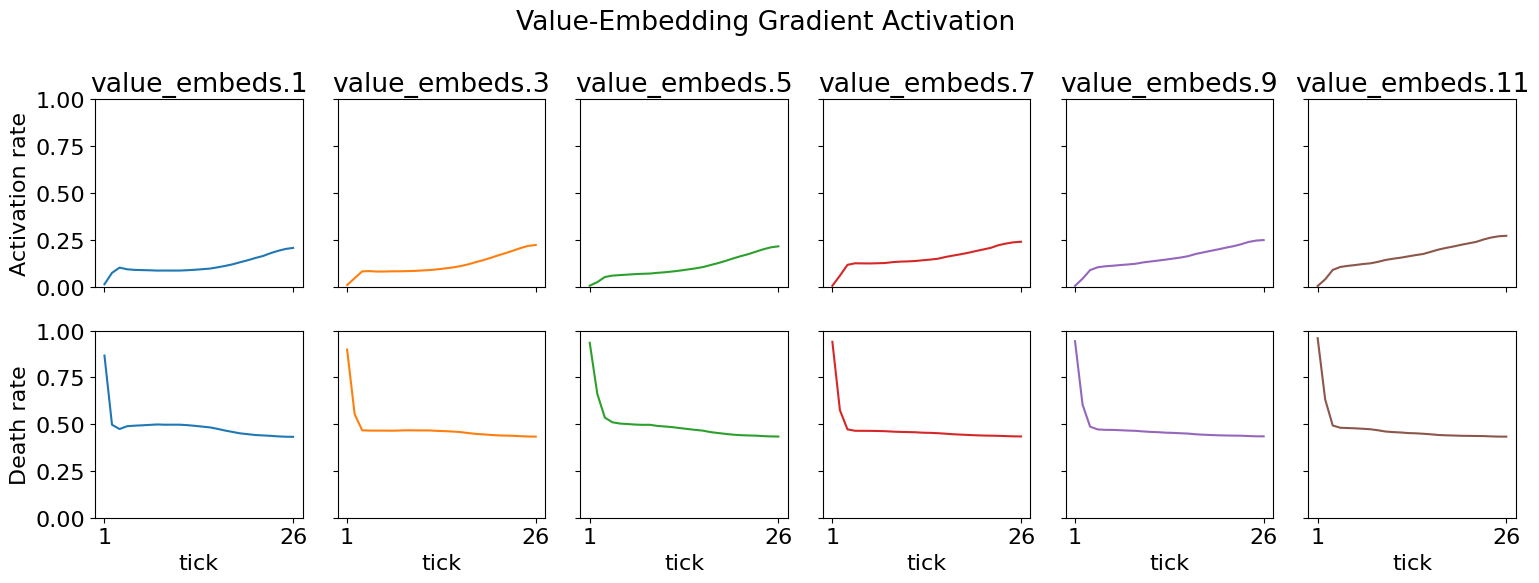

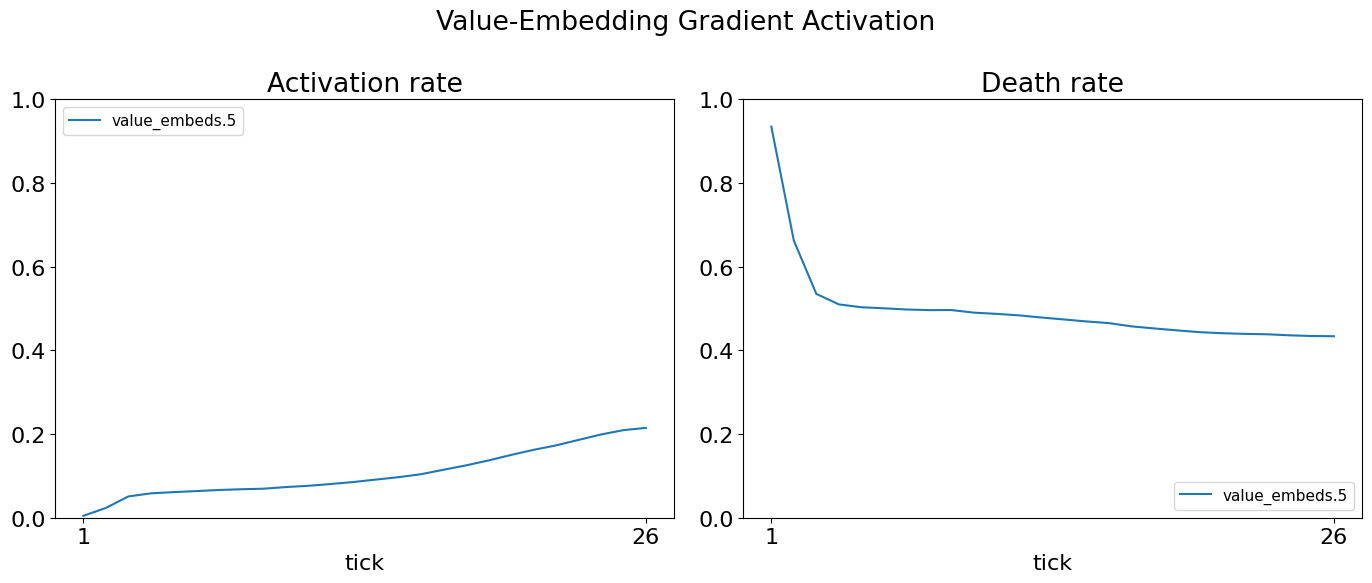

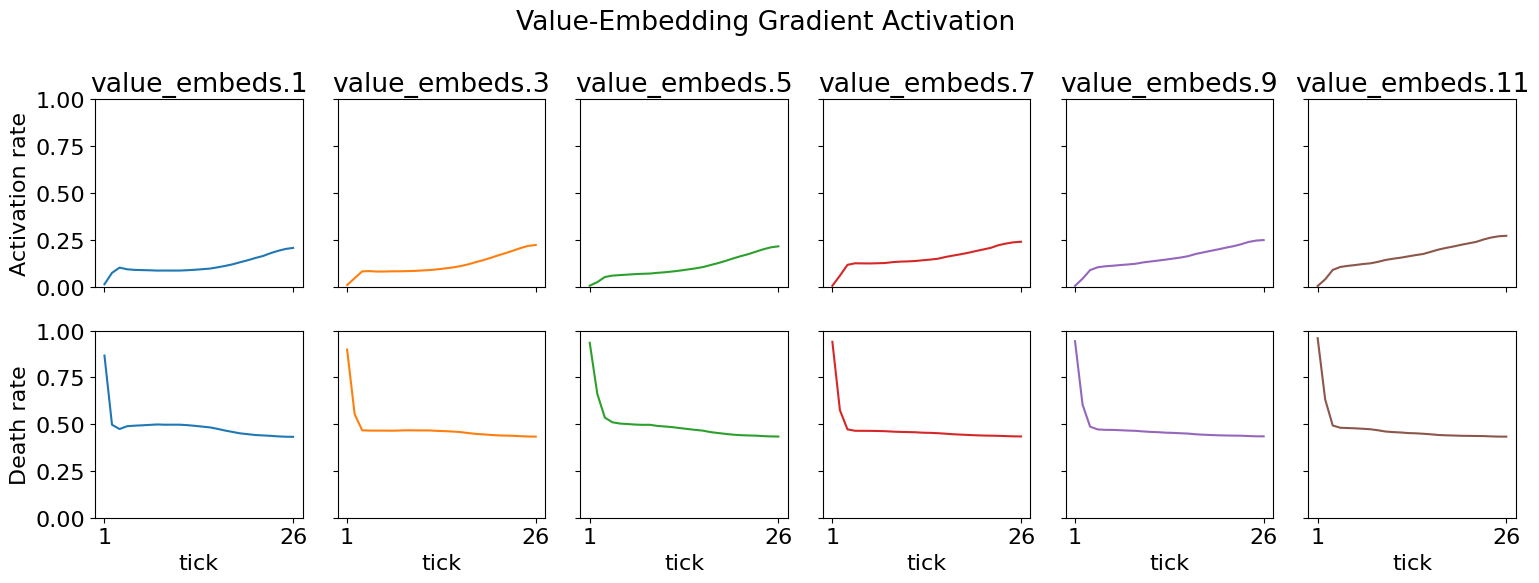

In [4]:
def make_fig_ve_death(ve_names, prefix=''):
    fig, [ax_act, ax_dead] = plt.subplots(ncols=2, figsize=(14, 6))
    fig.suptitle('Value-Embedding Gradient Activation')

    ax_act.set_title('Activation rate')
    plot_probability_lines(
        ax_act,
        probability_lines(baseline, 'Weight Gradient Activation', ve_names, 'activation_rate'),
    )
    ax_act.legend(fontsize=11, loc='upper left')

    ax_dead.set_title('Death rate')
    plot_probability_lines(
        ax_dead,
        probability_lines(baseline, 'Weight Gradient Activation', ve_names, 'death_rate'),
    )
    ax_dead.legend(fontsize=11, loc='lower right')

    for ax in (ax_act, ax_dead):
        ax.set_xlabel('tick')
        _set_xticks(ax)

    fig.tight_layout()
    fig.savefig(f'figs/{prefix}case_study_ve_death.pdf')
    return fig

def make_fig_ve_death_grid(ve_names, prefix='all_ve_'):
    """One column per VE, two rows (activation rate / death rate)."""
    n = len(ve_names)
    fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(2.6 * n, 6),
                             sharex='all', sharey='row', squeeze=False)
    fig.suptitle('Value-Embedding Gradient Activation')
    cycle = _color_cycle()
    for c, m in enumerate(ve_names):
        color = cycle[c % len(cycle)]
        data = baseline._to_plot['Weight Gradient Activation'][m]
        for r, key in enumerate(('activation_rate', 'death_rate')):
            ax = axes[r][c]
            xs = list(data[key].keys())
            ys = list(data[key].values())
            ax.plot(xs, ys, color=color)
            ax.set_ylim(0, 1)
            _set_xticks(ax)
        axes[0][c].set_title(_strip(m))
        axes[1][c].set_xlabel('tick')
    axes[0][0].set_ylabel('Activation rate')
    axes[1][0].set_ylabel('Death rate')
    fig.tight_layout()
    fig.savefig(f'figs/{prefix}case_study_ve_death.pdf')
    return fig

make_fig_ve_death(ve_names_for(SUBSET_INDICES))
make_fig_ve_death_grid(ve_names_for(ALL_INDICES), prefix='all_ve_')

# Fig 2 — VE parameter and gradient norms

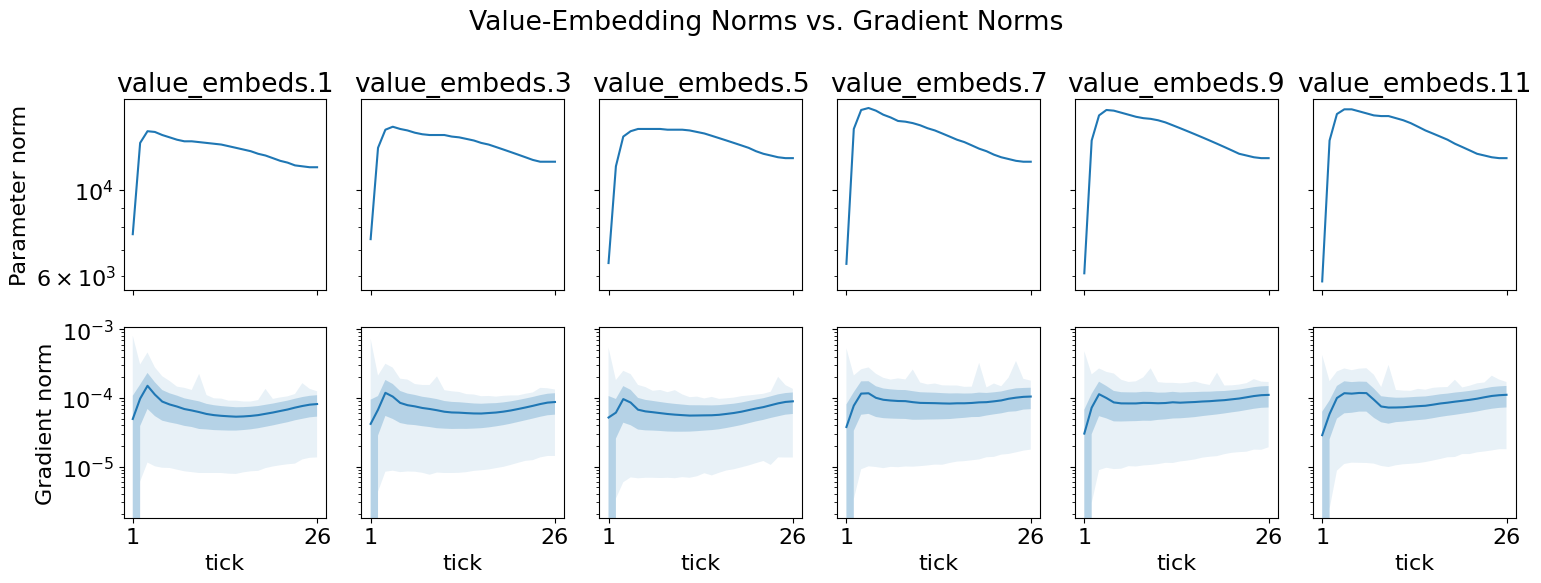

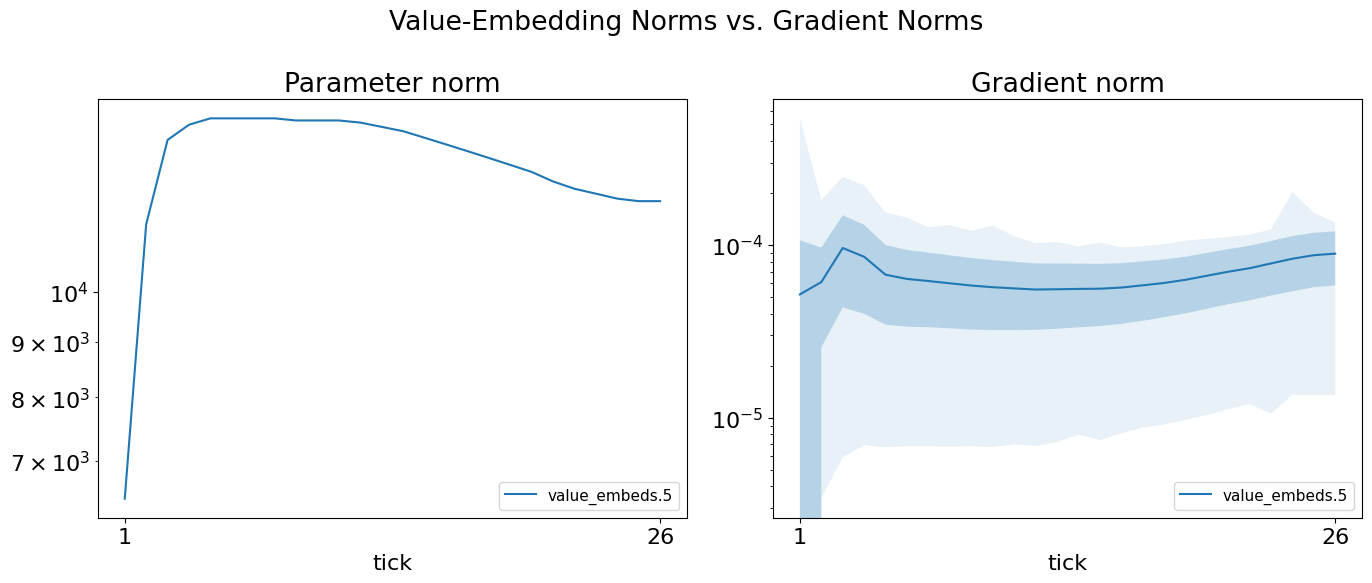

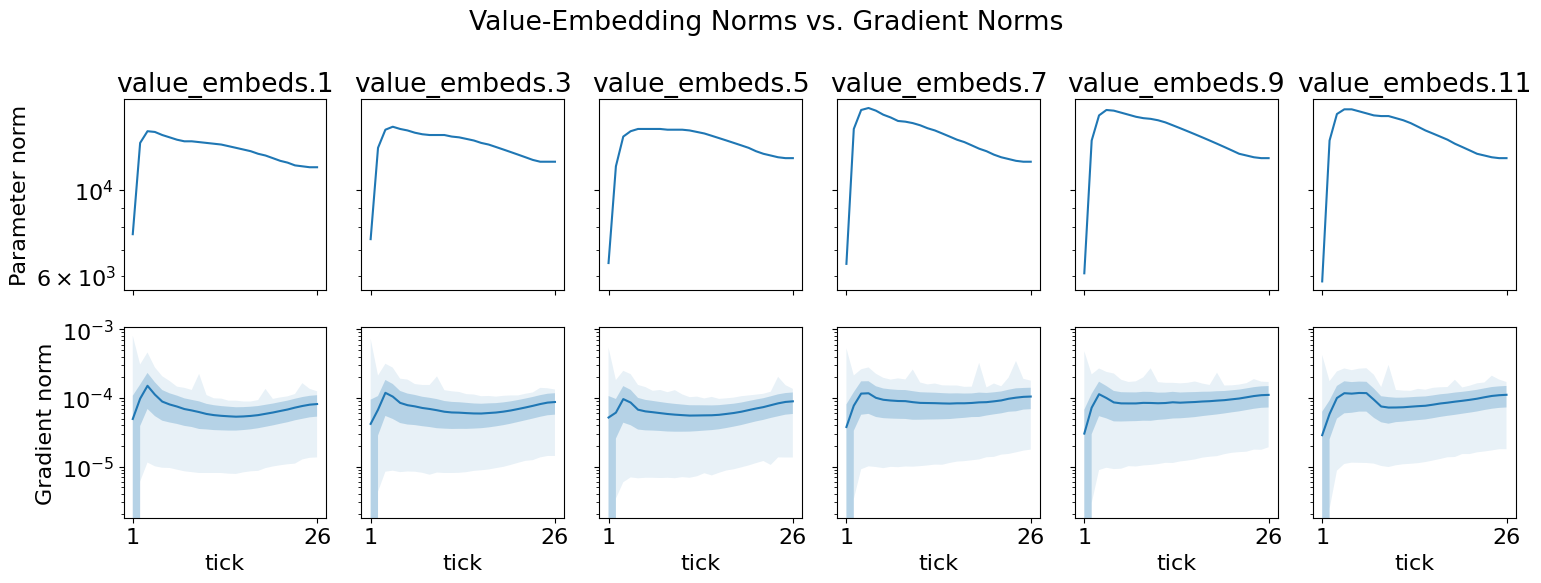

In [5]:
def make_fig_ve_norm(ve_names, prefix=''):
    fig, [ax_pn, ax_gn] = plt.subplots(ncols=2, figsize=(14, 6))
    fig.suptitle('Value-Embedding Norms vs. Gradient Norms')

    ax_pn.set_title('Parameter norm')
    plot_numerical_with_bands(ax_pn, baseline, 'Weight Norm', ve_names)
    ax_pn.set_yscale('log')
    ax_pn.legend(fontsize=11, loc='lower right')

    ax_gn.set_title('Gradient norm')
    plot_numerical_with_bands(ax_gn, baseline, 'Weight Gradient Norm', ve_names)
    ax_gn.set_yscale('log')
    ax_gn.legend(fontsize=11, loc='lower right')

    for ax in (ax_pn, ax_gn):
        ax.set_xlabel('tick')
        _set_xticks(ax)

    fig.tight_layout()
    fig.savefig(f'figs/{prefix}case_study_ve_norm.pdf')
    return fig

def make_fig_ve_norm_grid(ve_names, prefix='all_ve_'):
    """One column per VE, two rows (parameter norm / gradient norm)."""
    n = len(ve_names)
    fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(2.6 * n, 6),
                             sharex='all', sharey='row', squeeze=False)
    fig.suptitle('Value-Embedding Norms vs. Gradient Norms')
    rows = [('Weight Norm', 'Parameter norm'),
            ('Weight Gradient Norm', 'Gradient norm')]
    for c, m in enumerate(ve_names):
        for r, (main_tag, _) in enumerate(rows):
            ax = axes[r][c]
            plot_numerical_with_bands(ax, baseline, main_tag, [m])
            ax.set_yscale('log')
            _set_xticks(ax)
        axes[0][c].set_title(_strip(m))
        axes[1][c].set_xlabel('tick')
    for r, (_, ylabel) in enumerate(rows):
        axes[r][0].set_ylabel(ylabel)
    fig.tight_layout()
    fig.savefig(f'figs/{prefix}case_study_ve_norm.pdf')
    return fig

make_fig_ve_norm(ve_names_for(SUBSET_INDICES))
make_fig_ve_norm_grid(ve_names_for(ALL_INDICES), prefix='all_ve_')

# Fig 3 — Gate anomaly panel

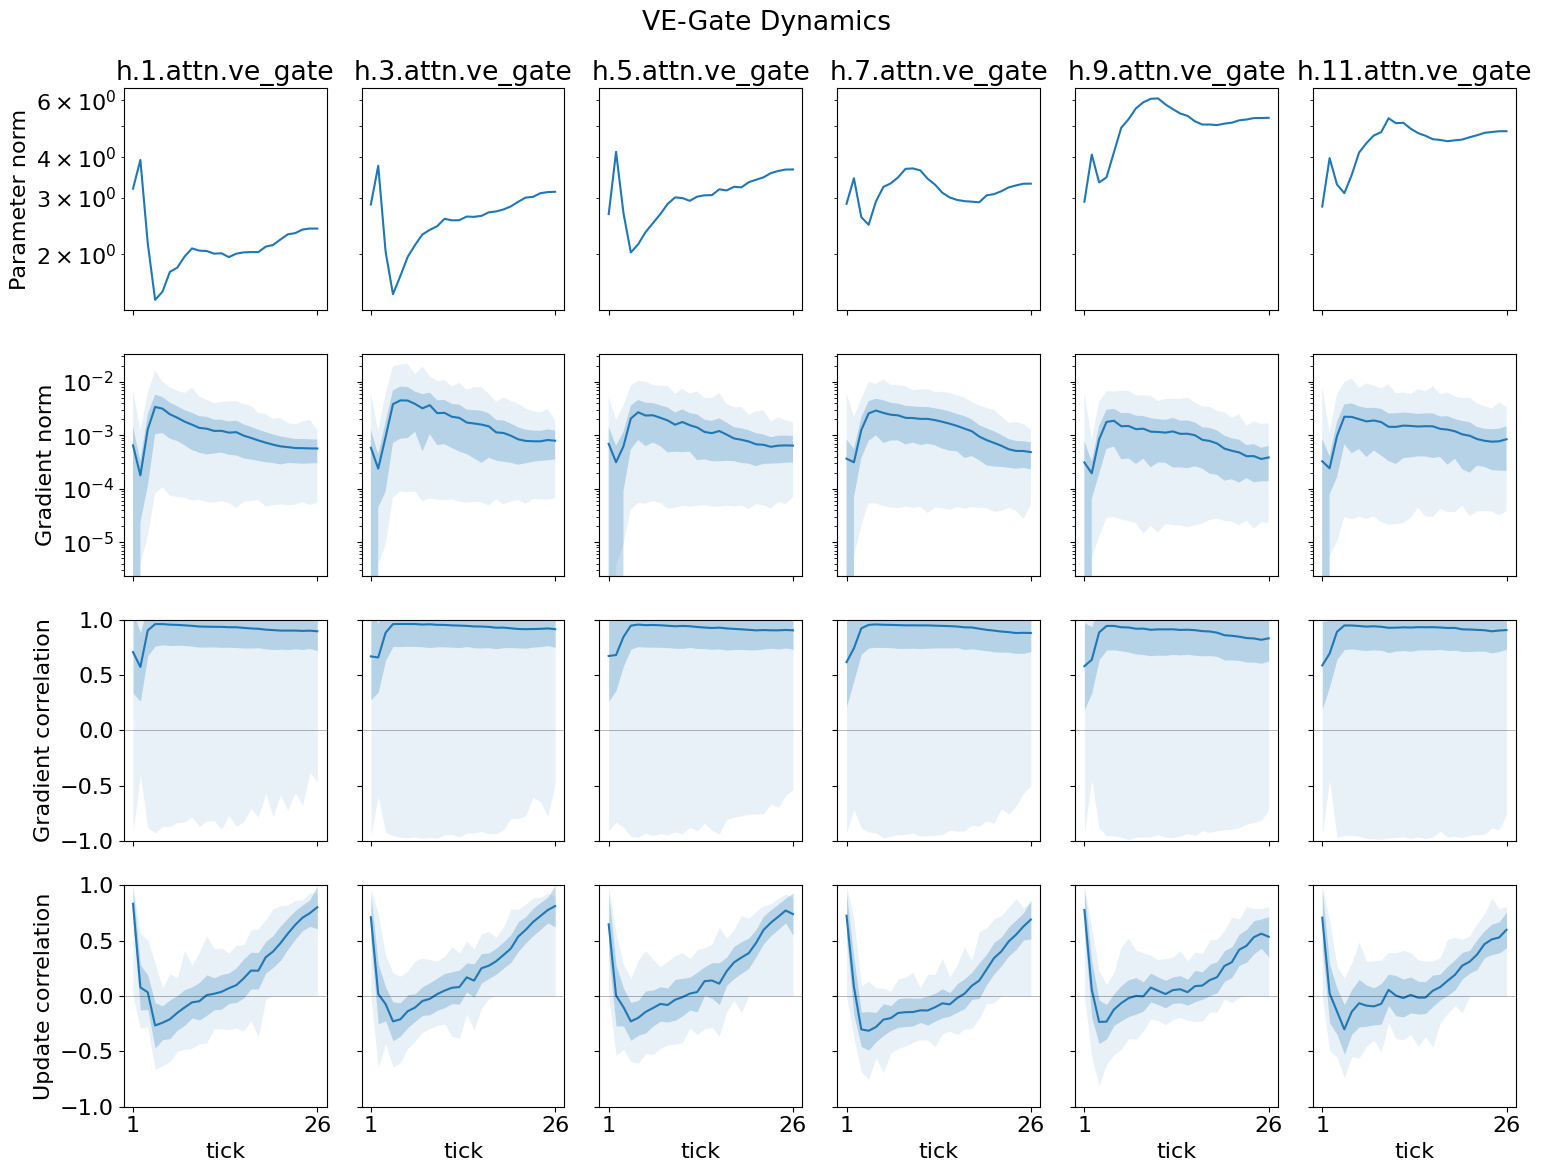

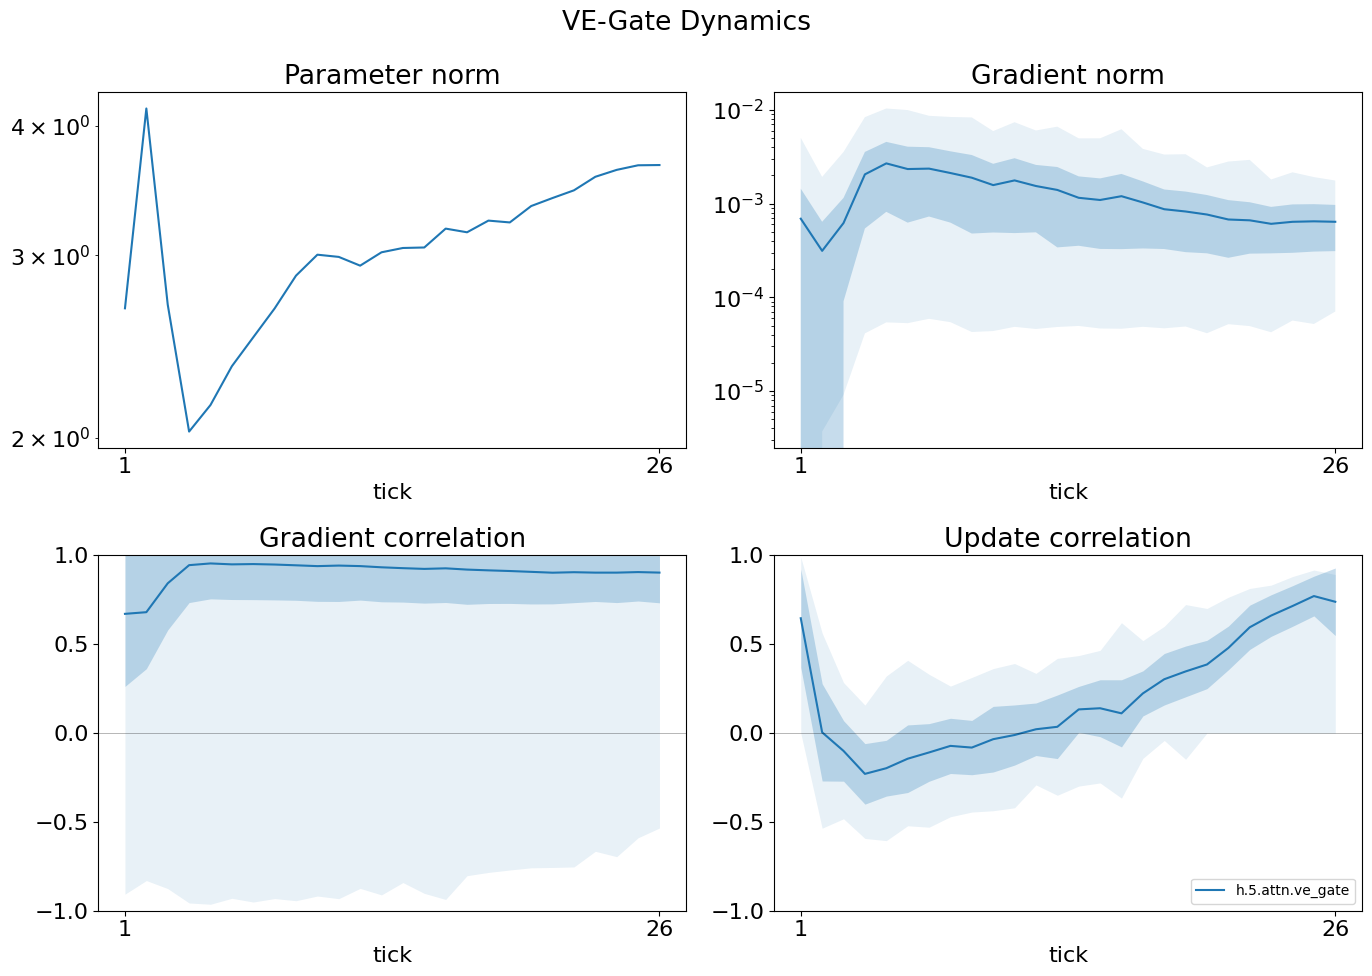

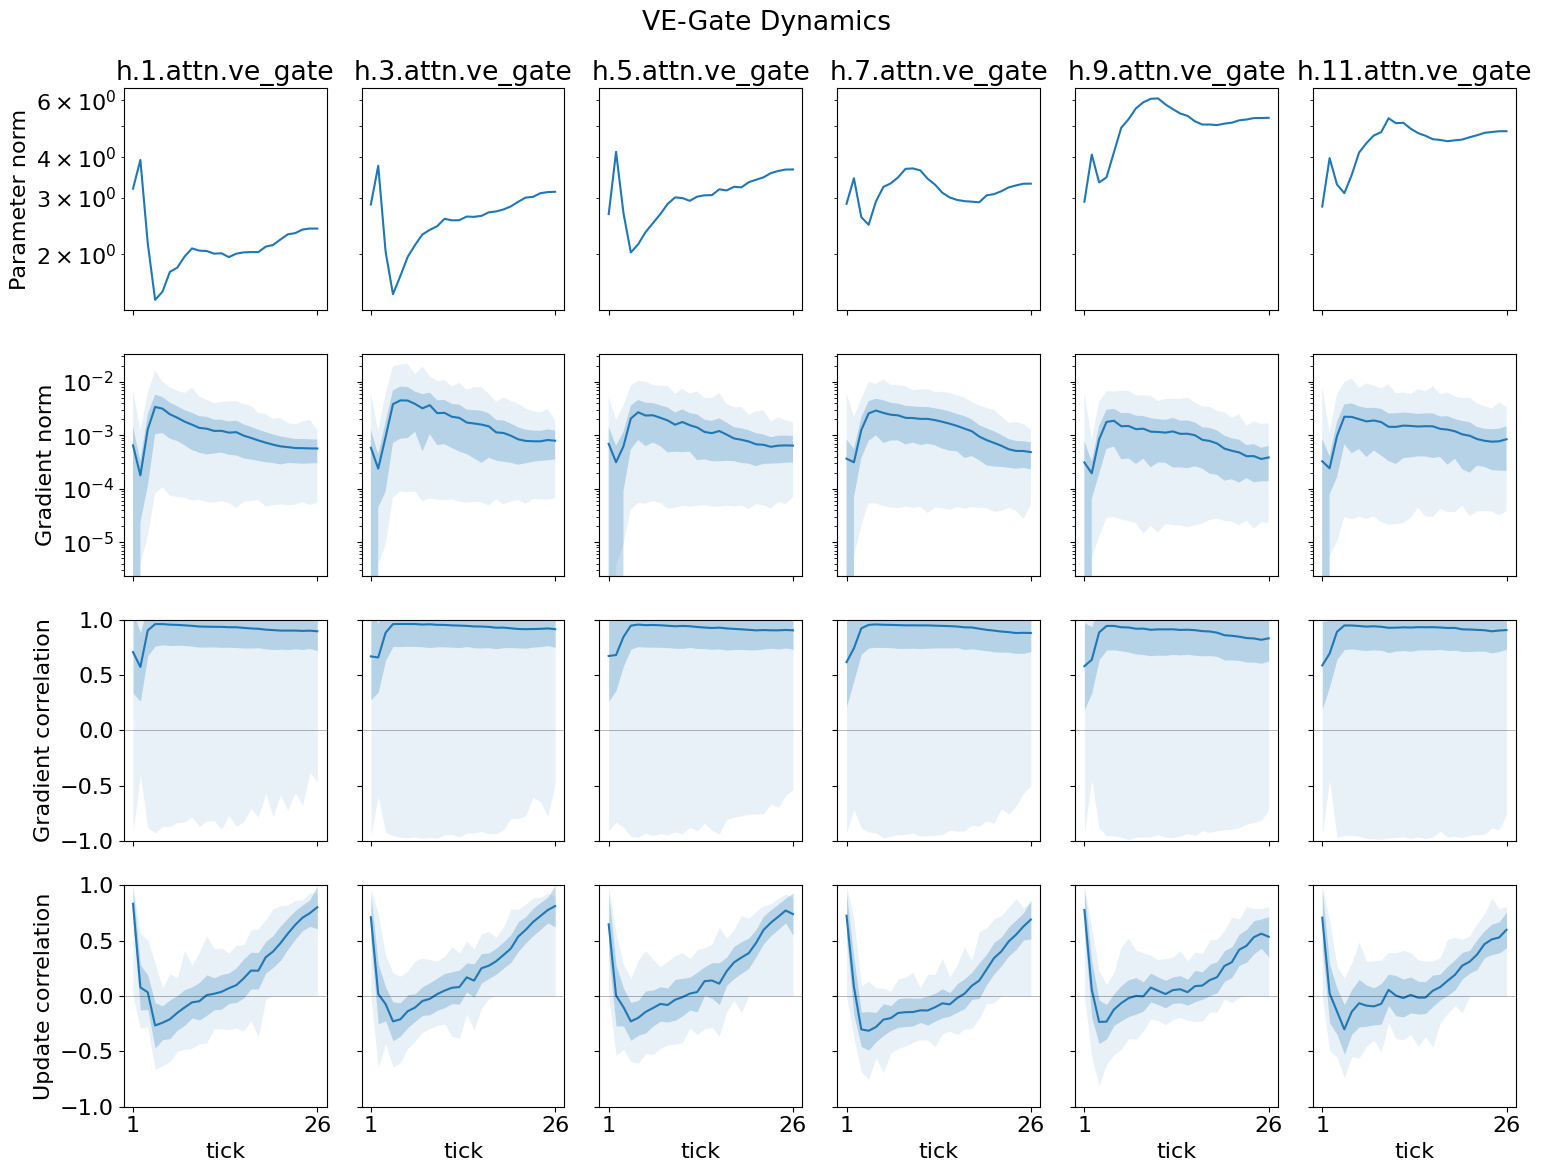

In [6]:
def lens_panel(fig, axes, visualizer, modules, suptitle):
    (ax_pn, ax_gn), (ax_gc, ax_uc) = axes
    fig.suptitle(suptitle)

    ax_pn.set_title('Parameter norm')
    plot_numerical_with_bands(ax_pn, visualizer, 'Weight Norm', modules)
    ax_pn.set_yscale('log')

    ax_gn.set_title('Gradient norm')
    plot_numerical_with_bands(ax_gn, visualizer, 'Weight Gradient Norm', modules)
    ax_gn.set_yscale('log')

    ax_gc.set_title('Gradient correlation')
    plot_numerical_with_bands(ax_gc, visualizer, 'Weight Gradient Correlation', modules)
    ax_gc.set_ylim(-1, 1)
    ax_gc.axhline(0.0, color='black', lw=0.5, alpha=0.4)

    ax_uc.set_title('Update correlation')
    plot_numerical_with_bands(ax_uc, visualizer, 'Weight Update Correlation', modules)
    ax_uc.set_ylim(-1, 1)
    ax_uc.axhline(0.0, color='black', lw=0.5, alpha=0.4)
    ax_uc.legend(fontsize=10, loc='lower right')

    for row in axes:
        for ax in row:
            ax.set_xlabel('tick')
            _set_xticks(ax)

def make_fig_gate_anomaly(gate_names, prefix=''):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    lens_panel(fig, axes, baseline, gate_names, 'VE-Gate Dynamics')
    fig.tight_layout()
    fig.savefig(f'figs/{prefix}case_study_gate_anomaly.pdf')
    return fig

_LENS_ROWS = [
    ('Weight Norm',                 'Parameter norm',       'log'),
    ('Weight Gradient Norm',        'Gradient norm',        'log'),
    ('Weight Gradient Correlation', 'Gradient correlation', 'corr'),
    ('Weight Update Correlation',   'Update correlation',   'corr'),
]

def _lens_grid(visualizer, modules, suptitle, savefile):
    """4 rows (param norm / grad norm / grad corr / update corr) × N cols."""
    n = len(modules)
    fig, axes = plt.subplots(nrows=4, ncols=n, figsize=(2.6 * n, 12),
                             sharex='all', sharey='row', squeeze=False)
    fig.suptitle(suptitle)
    for c, m in enumerate(modules):
        for r, (main_tag, _, mode) in enumerate(_LENS_ROWS):
            ax = axes[r][c]
            plot_numerical_with_bands(ax, visualizer, main_tag, [m])
            if mode == 'log':
                ax.set_yscale('log')
            elif mode == 'corr':
                ax.set_ylim(-1, 1)
                ax.axhline(0.0, color='black', lw=0.5, alpha=0.4)
            _set_xticks(ax)
        axes[0][c].set_title(_strip(m))
        axes[-1][c].set_xlabel('tick')
    for r, (_, ylabel, _) in enumerate(_LENS_ROWS):
        axes[r][0].set_ylabel(ylabel)
    fig.tight_layout()
    fig.savefig(savefile)
    return fig

def make_fig_gate_anomaly_grid(gate_names, prefix='all_ve_'):
    return _lens_grid(baseline, gate_names, 'VE-Gate Dynamics',
                      f'figs/{prefix}case_study_gate_anomaly.pdf')

make_fig_gate_anomaly(gate_names_for(SUBSET_INDICES))
make_fig_gate_anomaly_grid(gate_names_for(ALL_INDICES), prefix='all_ve_')

# Fig 4 — Healthy reference panel

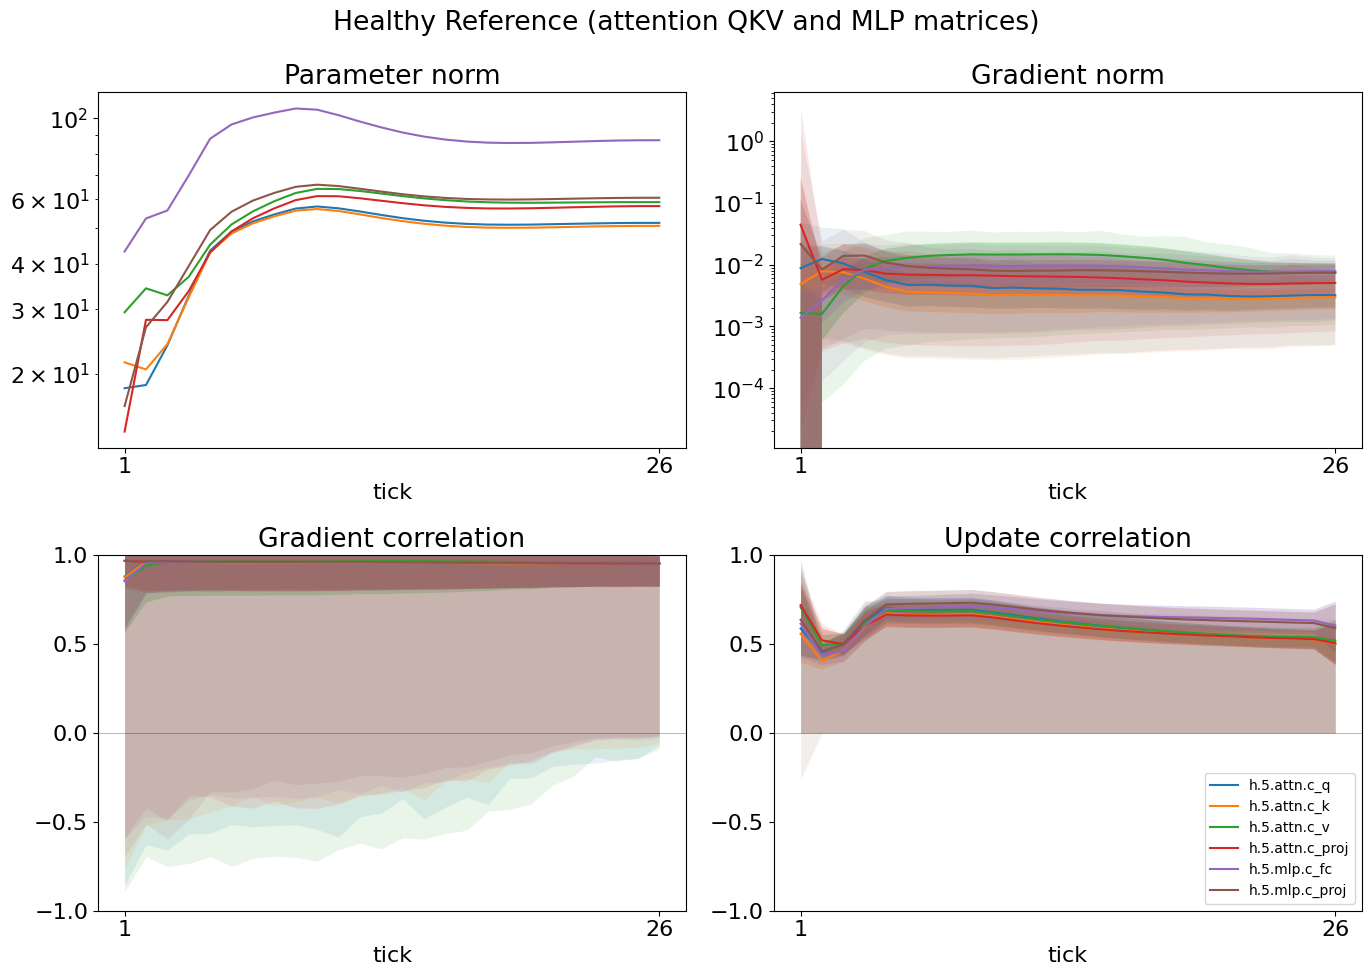

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
lens_panel(fig, axes, baseline, HEALTHY_NAMES, 'Healthy Reference (attention QKV and MLP matrices)')
fig.tight_layout()
fig.savefig('figs/case_study_healthy.pdf')

# Fig 5 — Effect of ve_dropout=0.5

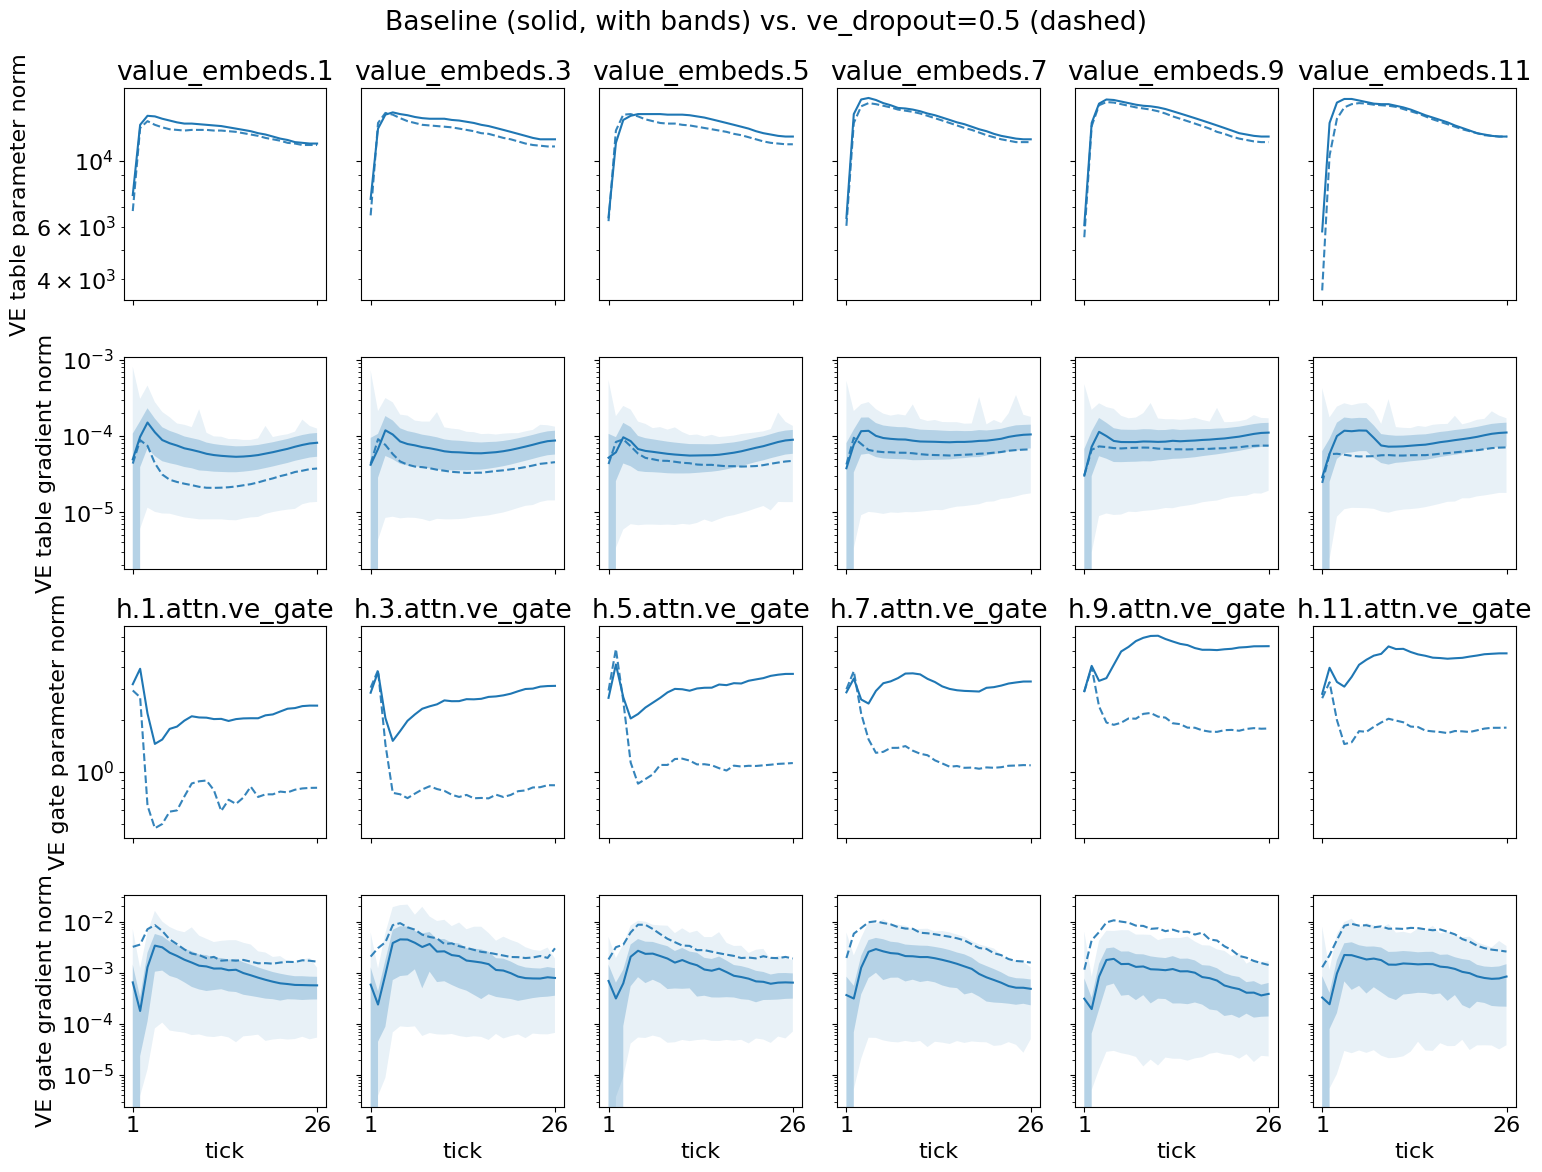

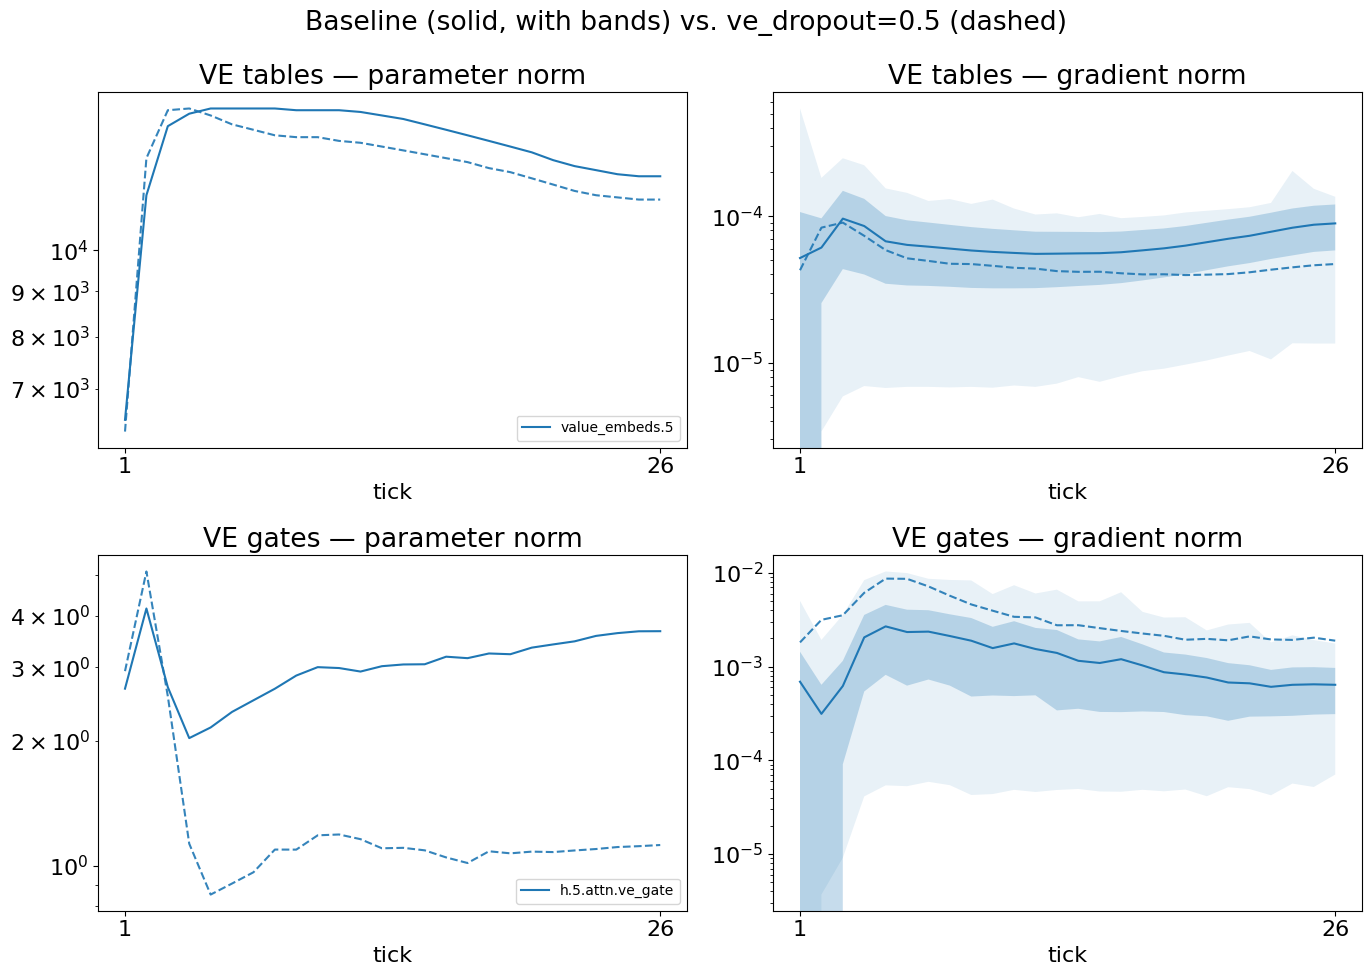

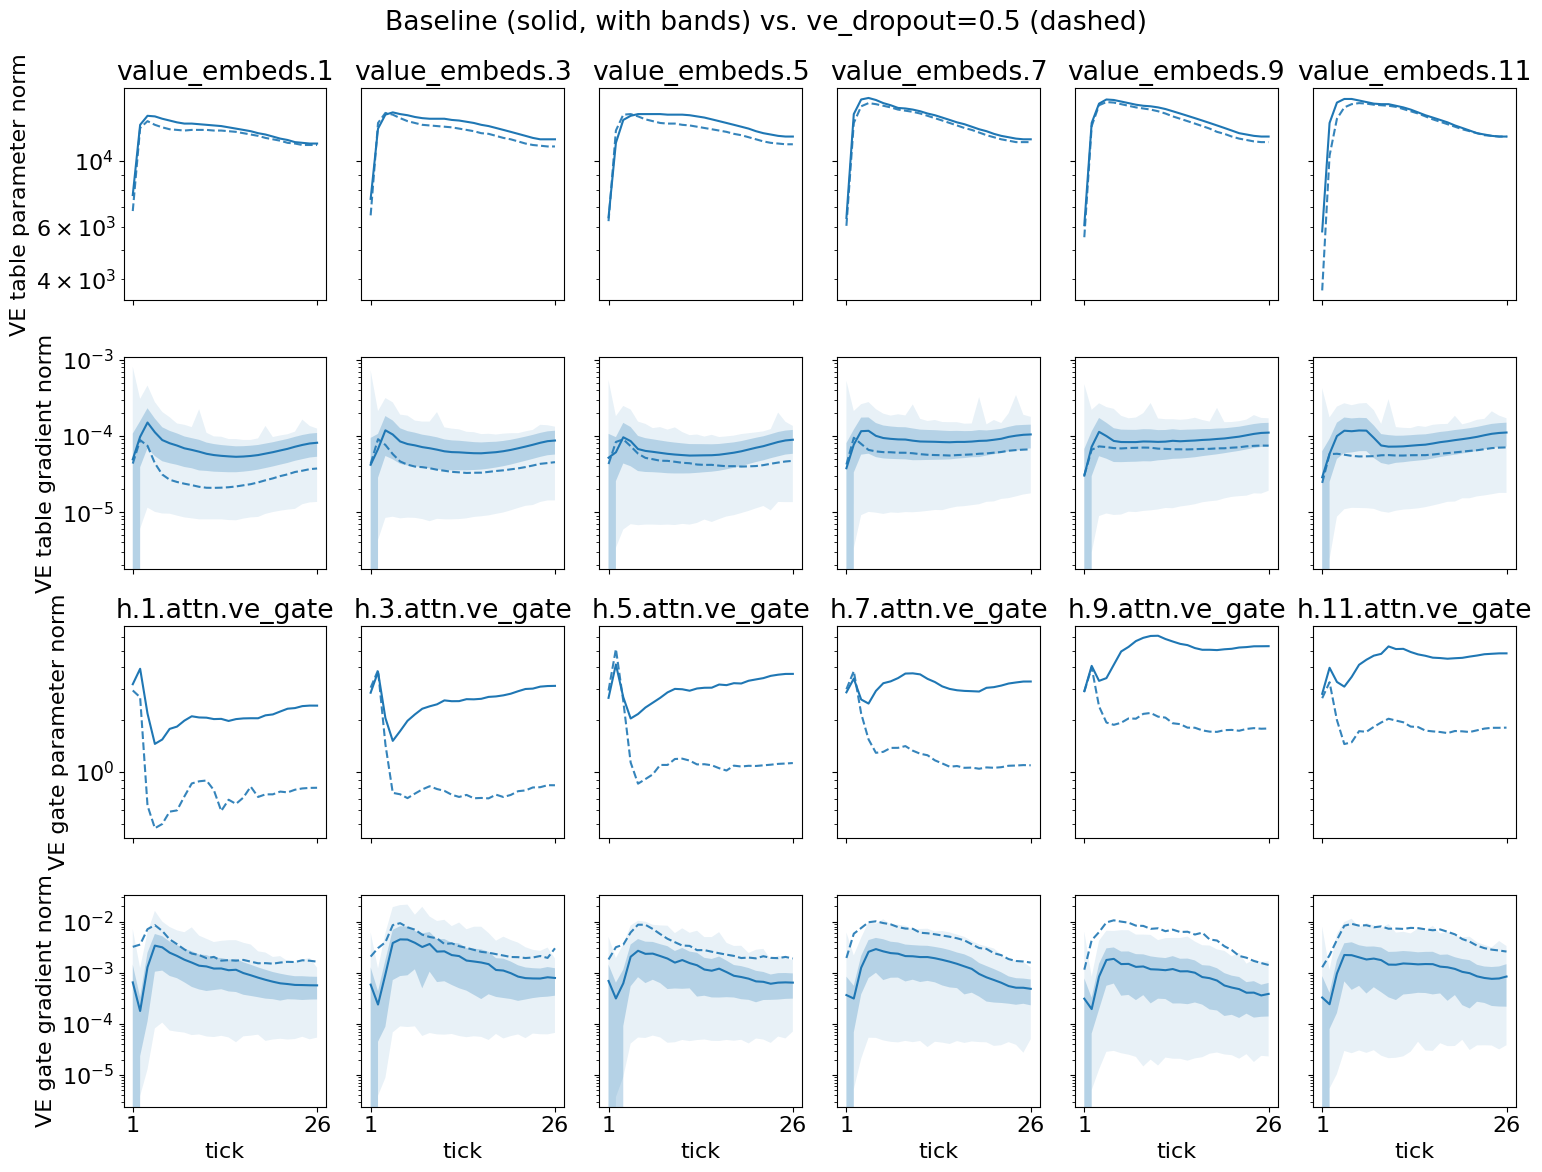

In [8]:
def overlay_numerical(ax, base_v, do_v, main_tag, modules, descriptor='mean'):
    """Baseline lines + bands (solid), dropout lines as dashed overlay (no bands)."""
    plot_numerical_with_bands(ax, base_v, main_tag, modules, descriptor=descriptor)
    color_for = {}
    cycle = _color_cycle()
    for i, m in enumerate(modules):
        color_for[_strip(m)] = cycle[i % len(cycle)]
    do_lines = numerical_lines(do_v, main_tag, modules, descriptor)
    for label, series in do_lines.items():
        ax.plot(list(series.keys()), list(series.values()),
                color=color_for.get(label), linestyle='--', alpha=0.9)

def make_fig_ve_dropout(ve_names, gate_names, prefix=''):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    (ax_ve_pn, ax_ve_gn), (ax_g_pn, ax_g_gn) = axes
    fig.suptitle('Baseline (solid, with bands) vs. ve_dropout=0.5 (dashed)')

    ax_ve_pn.set_title('VE tables — parameter norm')
    overlay_numerical(ax_ve_pn, baseline, do05, 'Weight Norm', ve_names)
    ax_ve_pn.set_yscale('log')
    ax_ve_pn.legend(fontsize=10, loc='lower right')

    ax_ve_gn.set_title('VE tables — gradient norm')
    overlay_numerical(ax_ve_gn, baseline, do05, 'Weight Gradient Norm', ve_names)
    ax_ve_gn.set_yscale('log')

    ax_g_pn.set_title('VE gates — parameter norm')
    overlay_numerical(ax_g_pn, baseline, do05, 'Weight Norm', gate_names)
    ax_g_pn.set_yscale('log')
    ax_g_pn.legend(fontsize=10, loc='lower right')

    ax_g_gn.set_title('VE gates — gradient norm')
    overlay_numerical(ax_g_gn, baseline, do05, 'Weight Gradient Norm', gate_names)
    ax_g_gn.set_yscale('log')

    for row in axes:
        for ax in row:
            ax.set_xlabel('tick')
            _set_xticks(ax)

    fig.tight_layout()
    fig.savefig(f'figs/{prefix}ve_dropout.pdf')
    return fig

def make_fig_ve_dropout_grid(ve_names, gate_names, prefix='all_ve_'):
    """4 rows × N cols. Rows: VE param norm / VE grad norm / gate param norm / gate grad norm."""
    assert len(ve_names) == len(gate_names), 'parallel ve and gate columns expected'
    n = len(ve_names)
    fig, axes = plt.subplots(nrows=4, ncols=n, figsize=(2.6 * n, 12),
                             sharex='all', sharey='row', squeeze=False)
    fig.suptitle('Baseline (solid, with bands) vs. ve_dropout=0.5 (dashed)')
    rows = [
        ('Weight Norm',          ve_names,   'VE table parameter norm'),
        ('Weight Gradient Norm', ve_names,   'VE table gradient norm'),
        ('Weight Norm',          gate_names, 'VE gate parameter norm'),
        ('Weight Gradient Norm', gate_names, 'VE gate gradient norm'),
    ]
    for r, (main_tag, modules, ylabel) in enumerate(rows):
        for c, m in enumerate(modules):
            ax = axes[r][c]
            overlay_numerical(ax, baseline, do05, main_tag, [m])
            ax.set_yscale('log')
            _set_xticks(ax)
        axes[r][0].set_ylabel(ylabel)
    for c, (m_ve, m_g) in enumerate(zip(ve_names, gate_names)):
        axes[0][c].set_title(_strip(m_ve))
        axes[2][c].set_title(_strip(m_g))
    for ax in axes[-1]:
        ax.set_xlabel('tick')
    fig.tight_layout()
    fig.savefig(f'figs/{prefix}ve_dropout.pdf')
    return fig

make_fig_ve_dropout(ve_names_for(SUBSET_INDICES), gate_names_for(SUBSET_INDICES))
make_fig_ve_dropout_grid(ve_names_for(ALL_INDICES), gate_names_for(ALL_INDICES), prefix='all_ve_')